## Homework 3 (KNN)
Дз по KNN-ну (я использовал датасет Anemia Types Classification https://www.kaggle.com/datasets/ehababoelnaga/anemia-types-classification/data?select=diagnosed_cbc_data_v4.csv) 

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('diagnosed_cbc_data_v4.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1281 entries, 0 to 1280
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   WBC        1281 non-null   float64
 1   LYMp       1281 non-null   float64
 2   NEUTp      1281 non-null   float64
 3   LYMn       1281 non-null   float64
 4   NEUTn      1281 non-null   float64
 5   RBC        1281 non-null   float64
 6   HGB        1281 non-null   float64
 7   HCT        1281 non-null   float64
 8   MCV        1281 non-null   float64
 9   MCH        1281 non-null   float64
 10  MCHC       1281 non-null   float64
 11  PLT        1281 non-null   float64
 12  PDW        1281 non-null   float64
 13  PCT        1281 non-null   float64
 14  Diagnosis  1281 non-null   str    
dtypes: float64(14), str(1)
memory usage: 150.2 KB


## Обзор датасета

Датасет не имеет пропусков, типы данных вполне адекватные, датасет достаточно большой (1281 сэмплов), различных классов много, а именно:

In [3]:
diagnoses = pd.Series(df['Diagnosis'].unique())
print(diagnoses)
print('количество классов - {}'.format(len(diagnoses)))


0     Normocytic hypochromic anemia
1            Iron deficiency anemia
2           Other microcytic anemia
3                          Leukemia
4                           Healthy
5                  Thrombocytopenia
6    Normocytic normochromic anemia
7    Leukemia with thrombocytopenia
8                 Macrocytic anemia
dtype: str
количество классов - 9


И по количеству сэмплов разные классы насчитывают:

In [4]:
print(pd.DataFrame({diagnosis: df[df['Diagnosis'] == diagnosis].shape[0] for diagnosis in diagnoses}.items()))

                                0    1
0   Normocytic hypochromic anemia  279
1          Iron deficiency anemia  189
2         Other microcytic anemia   59
3                        Leukemia   47
4                         Healthy  336
5                Thrombocytopenia   73
6  Normocytic normochromic anemia  269
7  Leukemia with thrombocytopenia   11
8               Macrocytic anemia   18


Теперь посмотрим на распределения данных:

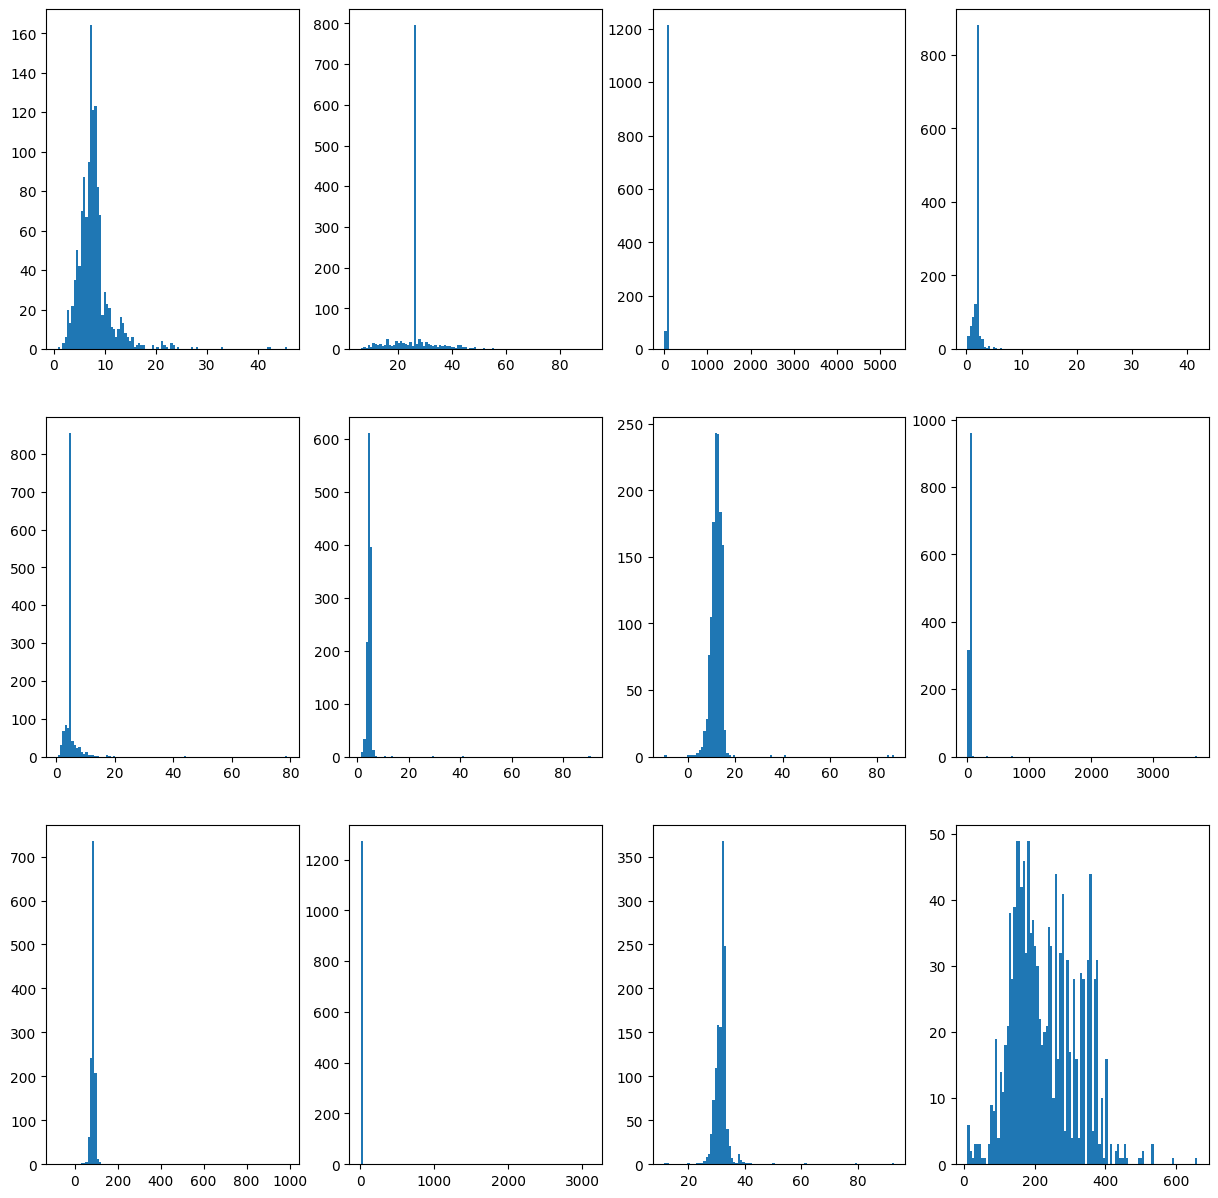

In [5]:
from matplotlib import pyplot as plt

for ax, title in zip(plt.figure(figsize=(15,15)).subplots(3, 4).ravel(), df.select_dtypes('number').columns):
    ax.hist(df[title].values, bins=100)
    ax.set_xlabel('')


Посмотрим на то, как признаки распределены по значениям (сильно ли отличаются диапазоны), просчитаем это и визуализируем.

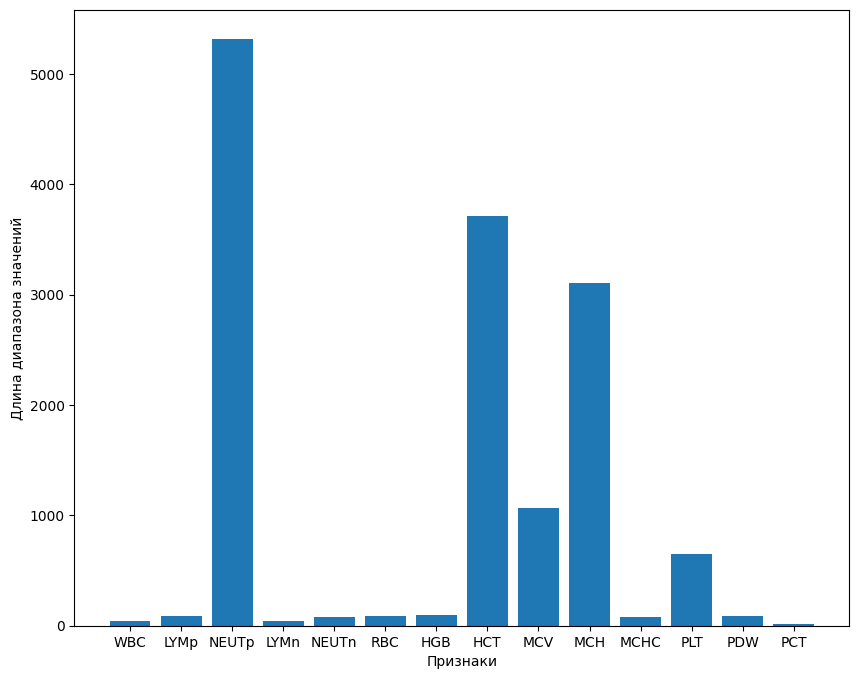

In [6]:


column_ranges = pd.Series(abs(df.select_dtypes('number').max().values - df.select_dtypes('number').min().values), index=df.select_dtypes('number').columns)
plt.figure(figsize=(10, 8))
plt.bar(range(len(column_ranges)), column_ranges)
plt.xticks(range(len(column_ranges)), column_ranges.index)
plt.xlabel('Признаки')
plt.ylabel('Длина диапазона значений')
plt.show()

Как видно на графике, разброс между диапазонами по величинам большой, поэтому нужно занятся масштабированием (в следующем пункте), т.к. в KNN используются метрики, которые чувствительны к таким различиям. KNN использует метрики, являющиеся расстоянием и веса сщседей обычно тоже выбираются в зависимости от расстояния до предсказываемого экземпляра, поэтому шаг с масштабированием - обязательный (особенно в случае этих конкретных данных, т.к. очень большой разброс)

Теперь еще проверим корреляцию с помощью heatmap.

<Axes: >

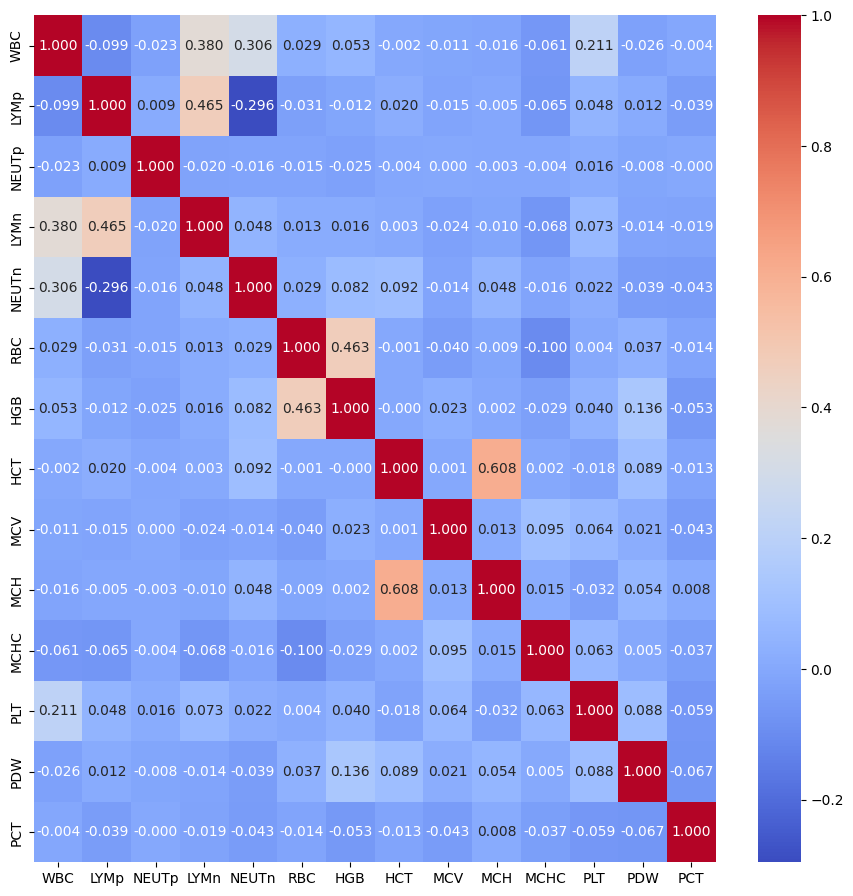

In [7]:
import seaborn as sns
plt.figure(figsize= (11,11))
sns.heatmap(df.select_dtypes('number').corr(), annot=True, fmt=".3f", cmap='coolwarm')

Как видно на графике, признаки почти не коррелируются.

## Подготовка данных
Для начала сделаем таргет не строковым, а числовым значением с помощью `OrdinalEncoder`.

In [8]:
from sklearn.preprocessing import OrdinalEncoder

ec = OrdinalEncoder()
df_encoded = df.select_dtypes('number').join(pd.DataFrame(np.int64(ec.fit_transform(pd.DataFrame(df['Diagnosis'])))))
df_encoded.columns = df.columns

df_encoded.head()

,WBC,LYMp,NEUTp,LYMn,NEUTn,RBC,HGB,HCT,MCV,MCH,MCHC,PLT,PDW,PCT,Diagnosis
0,10.0,43.2,50.1,4.3,5.0,2.77,7.3,24.2,87.7,26.3,30.1,189.0,12.5,0.17,5
1,10.0,42.4,52.3,4.2,5.3,2.84,7.3,25.0,88.2,25.7,20.2,180.0,12.5,0.16,5
2,7.2,30.7,60.7,2.2,4.4,3.97,9.0,30.5,77.0,22.6,29.5,148.0,14.3,0.14,1
3,6.0,30.2,63.5,1.8,3.8,4.22,3.8,32.8,77.9,23.2,29.8,143.0,11.3,0.12,1
4,4.2,39.1,53.7,1.6,2.3,3.93,0.4,316.0,80.6,23.9,29.7,236.0,12.8,0.22,5


И еще получим маппинг этих числовых значений к исходным для удобства дальнейшей визуализации и понимания происходящего.

In [9]:
target_mapping = {name: index for index, name in enumerate(ec.categories_[0])}
reverse_target_mapping = {index: name for name, index in target_mapping.items()}
print(target_mapping)

{'Healthy': 0, 'Iron deficiency anemia': 1, 'Leukemia': 2, 'Leukemia with thrombocytopenia': 3, 'Macrocytic anemia': 4, 'Normocytic hypochromic anemia': 5, 'Normocytic normochromic anemia': 6, 'Other microcytic anemia': 7, 'Thrombocytopenia': 8}


Далее разделим датасет на  `df_train` и `df_test`.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df_encoded.select_dtypes('float64'), df_encoded['Diagnosis'], random_state=42)
df_train = pd.DataFrame(X_train).join(y_train)
df_train.columns = df_encoded.columns
df_test = pd.DataFrame(X_test).join(y_test)
df_test.columns = df_encoded.columns

df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   WBC        960 non-null    float64
 1   LYMp       960 non-null    float64
 2   NEUTp      960 non-null    float64
 3   LYMn       960 non-null    float64
 4   NEUTn      960 non-null    float64
 5   RBC        960 non-null    float64
 6   HGB        960 non-null    float64
 7   HCT        960 non-null    float64
 8   MCV        960 non-null    float64
 9   MCH        960 non-null    float64
 10  MCHC       960 non-null    float64
 11  PLT        960 non-null    float64
 12  PDW        960 non-null    float64
 13  PCT        960 non-null    float64
 14  Diagnosis  960 non-null    int64  
dtypes: float64(14), int64(1)
memory usage: 112.6 KB


In [11]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 321 entries, 0 to 320
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   WBC        321 non-null    float64
 1   LYMp       321 non-null    float64
 2   NEUTp      321 non-null    float64
 3   LYMn       321 non-null    float64
 4   NEUTn      321 non-null    float64
 5   RBC        321 non-null    float64
 6   HGB        321 non-null    float64
 7   HCT        321 non-null    float64
 8   MCV        321 non-null    float64
 9   MCH        321 non-null    float64
 10  MCHC       321 non-null    float64
 11  PLT        321 non-null    float64
 12  PDW        321 non-null    float64
 13  PCT        321 non-null    float64
 14  Diagnosis  321 non-null    int64  
dtypes: float64(14), int64(1)
memory usage: 37.7 KB


Также было бы неплохо приблизить распределения признаков к нормальным с помощью `QuantileTransformer`. Это неплохо сделать (как мы убедимся позже) чтобы конечный результат вышел лучше.

In [12]:
from sklearn.preprocessing import QuantileTransformer

tfn = QuantileTransformer(random_state=42, n_quantiles=df_train.shape[0], output_distribution='normal')
df_normal = pd.DataFrame(tfn.fit_transform(df_train.select_dtypes('float64'))).join(df_train['Diagnosis'])
df_normal.columns = df_train.columns
df_normal.head()

,WBC,LYMp,NEUTp,LYMn,NEUTn,RBC,HGB,HCT,MCV,MCH,MCHC,PLT,PDW,PCT,Diagnosis
0,-0.325866,0.054917,0.321735,0.100802,0.119209,-0.483445,0.330004,0.434076,0.086362,0.112631,0.164096,0.550676,1.260448,0.439827,6
1,0.730528,0.054917,0.321735,0.100802,0.119209,-1.047001,-0.570556,0.434076,0.927835,0.288871,-0.306631,-0.343836,0.119209,0.439827,5
2,0.019605,0.054917,0.321735,0.100802,0.119209,0.144257,0.166745,0.434076,0.294326,0.484914,0.164096,0.655740,-1.000648,0.439827,6
3,0.090298,0.054917,0.321735,0.100802,0.119209,0.144257,0.104743,0.434076,0.294326,0.484914,0.927835,0.795219,0.119209,0.439827,6
4,0.465892,0.054917,0.321735,0.100802,0.119209,0.827919,1.065263,0.434076,0.842739,0.872950,0.927835,1.215457,-0.484914,0.439827,0


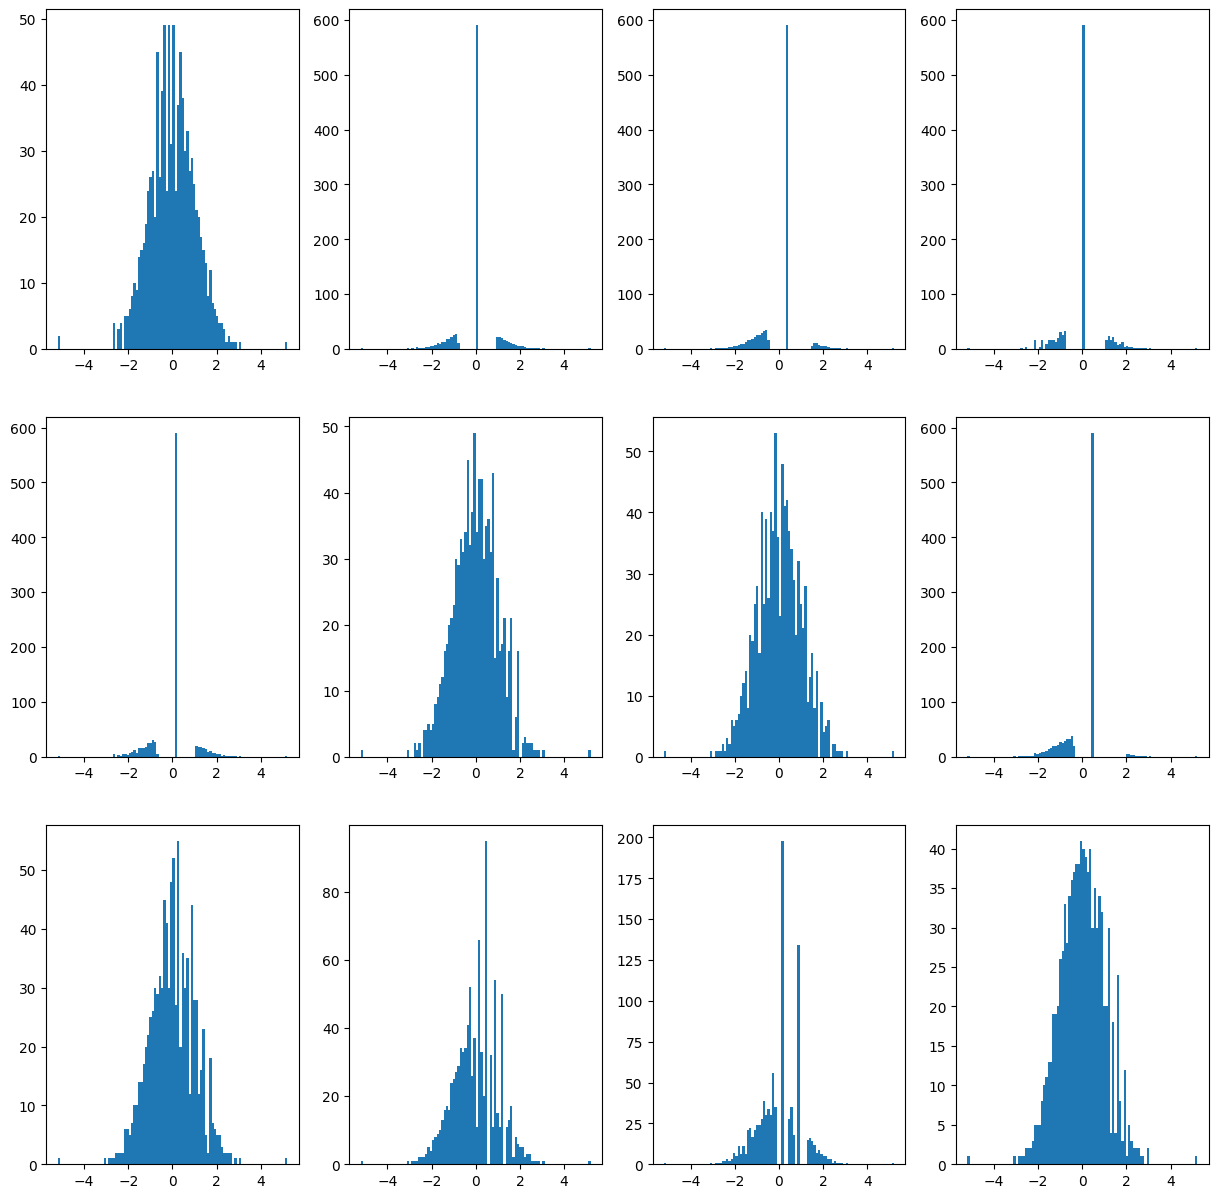

In [13]:
for ax, title in zip(plt.figure(figsize=(15,15)).subplots(3, 4).ravel(), df_normal.select_dtypes('number').columns):
    ax.hist(df_normal[title].values, bins=100)
    ax.set_xlabel('')

Сделаем еще для наглядности равномерное распределение также с помощью этого трансформера (в дальнейшем проверим какой из них лучше подходит).

In [14]:
tfu = QuantileTransformer(random_state=42, n_quantiles=df_train.shape[0], output_distribution='uniform')
df_uniform = pd.DataFrame(tfu.fit_transform(df_train.select_dtypes('float64'))).join(df_train['Diagnosis'])
df_uniform.columns = df_train.columns
df_uniform.head()

,WBC,LYMp,NEUTp,LYMn,NEUTn,RBC,HGB,HCT,MCV,MCH,MCHC,PLT,PDW,PCT,Diagnosis
0,0.372263,0.521898,0.626173,0.540146,0.547445,0.314390,0.629301,0.667883,0.534411,0.544838,0.565172,0.709072,0.896246,0.669969,6
1,0.767466,0.521898,0.626173,0.540146,0.547445,0.147550,0.284150,0.667883,0.823253,0.613660,0.379562,0.365485,0.547445,0.669969,5
2,0.507821,0.521898,0.626173,0.540146,0.547445,0.557351,0.566215,0.667883,0.615746,0.686131,0.565172,0.744004,0.158498,0.669969,6
3,0.535975,0.521898,0.626173,0.540146,0.547445,0.557351,0.541710,0.667883,0.615746,0.686131,0.823253,0.786757,0.547445,0.669969,6
4,0.679353,0.521898,0.626173,0.540146,0.547445,0.796142,0.856621,0.667883,0.800313,0.808655,0.823253,0.887904,0.313869,0.669969,0


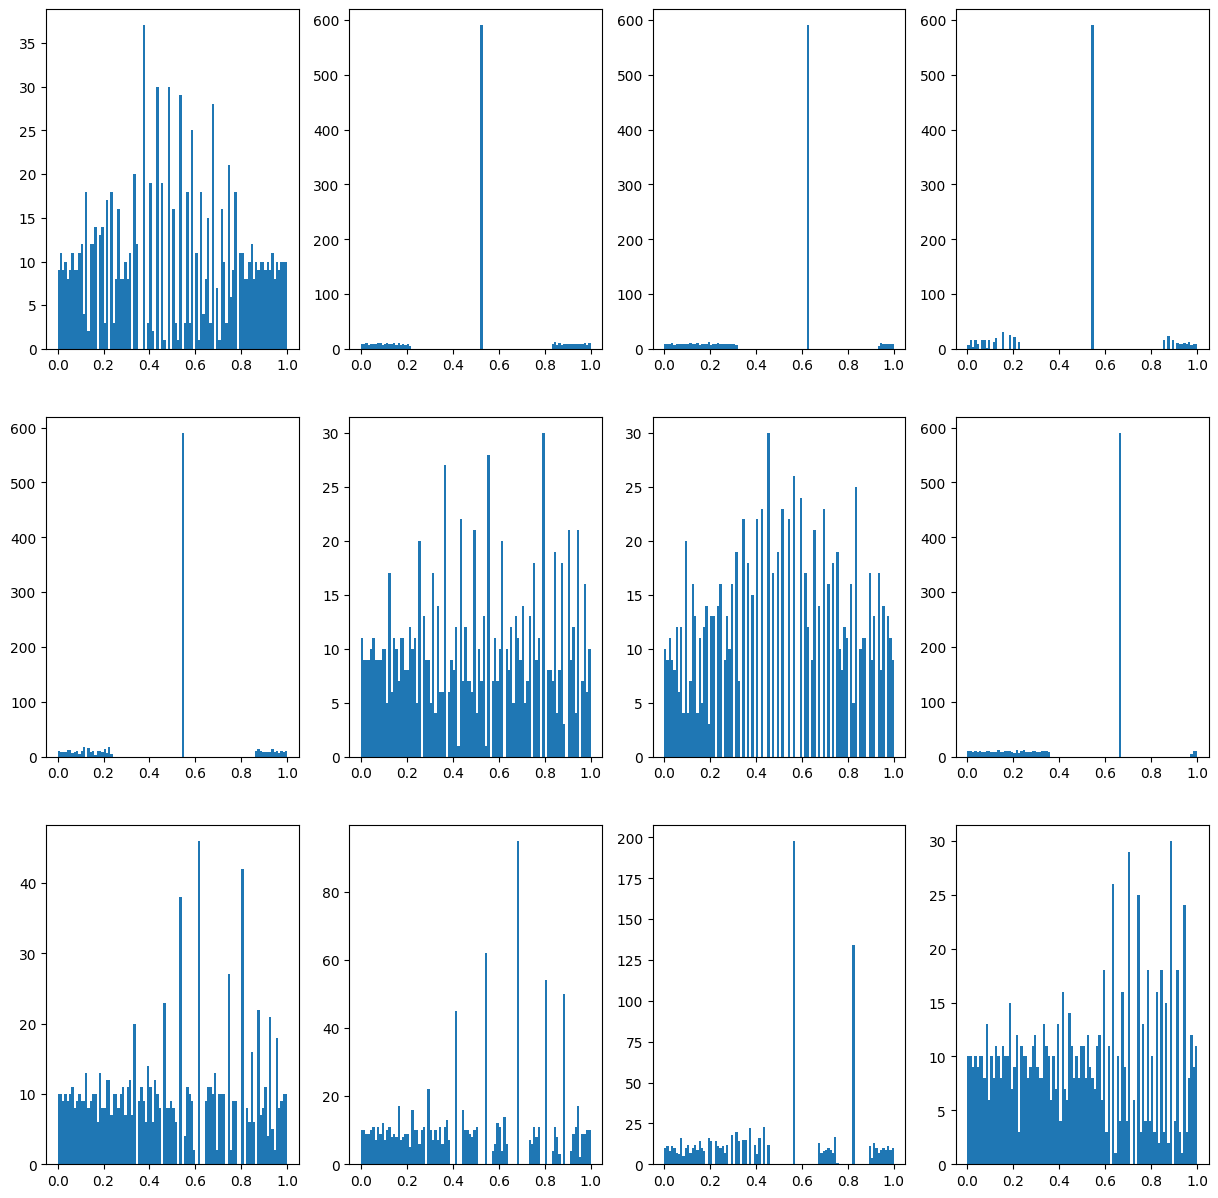

In [15]:
for ax, title in zip(plt.figure(figsize=(15,15)).subplots(3, 4).ravel(), df_uniform.select_dtypes('number').columns):
    ax.hist(df_uniform[title].values, bins=100)
    ax.set_xlabel('')

Важное замечание: все трансформации были произведены над тренировочным датасетом `df_train` чтобы тестовый датасет `df_test` был при проверке трансформирован независимо от первого, что мы и сделаем в следующей ячейке.

In [16]:
tfn = QuantileTransformer(random_state=42, n_quantiles=df_test.shape[0], output_distribution='normal')
df_normal_test = pd.DataFrame(tfn.fit_transform(df_test.select_dtypes('float64'))).join(df_test['Diagnosis'])
df_normal_test.columns = df_test.columns
print(df_normal_test.info())

tfu = QuantileTransformer(random_state=42, n_quantiles=df_test.shape[0], output_distribution='uniform')
df_uniform_test= pd.DataFrame(tfu.fit_transform(df_test.select_dtypes('float64'))).join(df_test['Diagnosis'])
df_uniform_test.columns = df_test.columns
print('\n')
print(df_uniform_test.info())

<class 'pandas.DataFrame'>
RangeIndex: 321 entries, 0 to 320
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   WBC        321 non-null    float64
 1   LYMp       321 non-null    float64
 2   NEUTp      321 non-null    float64
 3   LYMn       321 non-null    float64
 4   NEUTn      321 non-null    float64
 5   RBC        321 non-null    float64
 6   HGB        321 non-null    float64
 7   HCT        321 non-null    float64
 8   MCV        321 non-null    float64
 9   MCH        321 non-null    float64
 10  MCHC       321 non-null    float64
 11  PLT        321 non-null    float64
 12  PDW        321 non-null    float64
 13  PCT        321 non-null    float64
 14  Diagnosis  321 non-null    int64  
dtypes: float64(14), int64(1)
memory usage: 37.7 KB
None


<class 'pandas.DataFrame'>
RangeIndex: 321 entries, 0 to 320
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -

## Реализация модели
Я решил для начала попробовать реализовать свою модель. Я реализую свой класс, унаследовав `base.BaseEstimator` чтобы потом использовать его как финальный этап в `Pipline` и чтобы были функции `set_params` и `get_params` для более удобного подбора гиперпараметров.

In [17]:
from sklearn.base import BaseEstimator

class KNN(BaseEstimator):

    def __init__(self, *, n_neighbors=10, weights='uniform', metric='euclidean', p=2):
        self.n_neighbors=n_neighbors
        self.weights=weights
        self.metric=metric
        self.p = p
    
    def fit(self, X, y):
        self.X = np.array(X)
        self.y = np.array(y)
        return self

    def predict(self, X):
        X = np.array(X)
        dist = self.knneighbours(X)
        predictions = np.zeros(X.shape[0])
        if self.weights == 'uniform':
            for i in range(X.shape[0]):
                predicted_classes = np.array([self.y[int(dist[i, idx, 0])] for idx in range(self.n_neighbors)]).astype(int)
                predictions[i] = np.argmax(np.bincount(predicted_classes))
        elif self.weights == 'distance':
            for i in range(X.shape[0]):
                predicted_classes = np.int64(np.array([self.y[int(dist[i, idx, 0])] for idx in range(self.n_neighbors)])).astype(int)
                weights = np.array([ 1 / (dist[i, idx, 1] + 1e-10) for idx in range(self.n_neighbors)])
                predictions[i] = np.argmax(np.bincount(predicted_classes, weights=weights))
        else:
            pass
            
        return predictions
    
    def knneighbours(self, X_raw):
        res = []
        if(np.ndim(X_raw) == 1):
            X = np.atleast_2d(X_raw)
        else:
            X = X_raw
            
        for i in range(X.shape[0]):
            Z = self.X
            if self.metric == 'euclidean':
                dist = np.sqrt(np.sum(((Z - X[i]) ** 2), axis=1))
            elif self.metric == 'minkowski':
                dist = np.power(np.sum(np.abs(Z - X[i]) ** self.p, axis=1), 1 / self.p)
            elif self.metric == 'manhattan':
                dist = np.sum(np.absolute(Z - X[i]), axis=1)
            elif self.metric == 'cosine':
                dist = 1.0 - (np.sum(Z * X[i], axis=1) / (np.sqrt(np.sum(Z ** 2, axis=1)) * np.sqrt(np.sum(X[i] ** 2)) + 1e-10))
            else:
                pass
            indices = np.argsort(dist)[0:self.n_neighbors]
            res.append([[idx, dist[idx]] for idx in indices])
        return np.array(res)

In [18]:
classifier_custom = KNN()
classifier_custom.fit(df_normal.select_dtypes('float64'), df_normal['Diagnosis'])

,n_neighbors,10
,weights,'uniform'
,metric,'euclidean'
,p,2


Теперь еще создадим экземпляр класса `KNeighborsClassifier` чтобы потом сравнить результаты.

In [19]:
from sklearn.neighbors import KNeighborsClassifier

classifier = KNeighborsClassifier(n_neighbors=10)
classifier.fit(df_normal.select_dtypes('float64'), df_normal['Diagnosis'])

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## Проверка результатов
Теперь попробуем посмотреть score моей модели и встроенной в sklearn. Для этого используем встоенные в sklearn функции подсчета score.

In [20]:
from sklearn import metrics

print(metrics.accuracy_score(df_normal_test['Diagnosis'], classifier.predict(df_normal_test.select_dtypes('float64'))))
print(metrics.f1_score(df_normal_test['Diagnosis'], classifier.predict(df_normal_test.select_dtypes('float64')), average=None))

0.7414330218068536
[0.83653846 0.8        0.46153846 0.         0.5        0.64556962
 0.77358491 0.66666667 0.57142857]


In [21]:
print(metrics.accuracy_score(df_normal_test['Diagnosis'], classifier_custom.predict(df_normal_test.select_dtypes('float64'))))
print(metrics.f1_score(df_normal_test['Diagnosis'], classifier_custom.predict(df_normal_test.select_dtypes('float64')), average=None))

0.7414330218068536
[0.83653846 0.8        0.46153846 0.         0.5        0.64556962
 0.77358491 0.66666667 0.57142857]


Получилось ровно одно и то же, что радует. Теперь проверим то же самое но для `df_uniform_test`.

In [22]:
classifier.fit(df_uniform.select_dtypes('float64'), df_uniform['Diagnosis'])
classifier_custom.fit(df_uniform.select_dtypes('float64'), df_uniform['Diagnosis'])


print(metrics.accuracy_score(df_uniform_test['Diagnosis'], classifier.predict(df_uniform_test.select_dtypes('float64'))))
print(metrics.f1_score(df_uniform_test['Diagnosis'], classifier.predict(df_uniform_test.select_dtypes('float64')), average=None))
print()

print(metrics.accuracy_score(df_uniform_test['Diagnosis'], classifier_custom.predict(df_uniform_test.select_dtypes('float64'))))
print(metrics.f1_score(df_uniform_test['Diagnosis'], classifier_custom.predict(df_uniform_test.select_dtypes('float64')), average=None))

0.7414330218068536
[0.85167464 0.7961165  0.42857143 0.         0.66666667 0.63513514
 0.78095238 0.71428571 0.4137931 ]

0.7414330218068536
[0.85167464 0.7961165  0.42857143 0.         0.66666667 0.63513514
 0.78095238 0.71428571 0.4137931 ]


И опять то же самое по accuracy но другое по F1 score (в целом лучше). Тут нужно сделать важное замечание, по поводу того, почему результат по пятому классу (Macrocytic anemia) равен 0. Это так, потому что в тестовом датасете почти нет экземпляров этого класса (ну или потому что модель плохо обучилась, трудно судить точно):

In [23]:
print(pd.DataFrame({reverse_target_mapping[diagnosis]: df_normal_test[df_normal_test['Diagnosis'] == diagnosis].shape[0] for diagnosis in target_mapping.values()}.items()))

                                0    1
0                         Healthy  103
1          Iron deficiency anemia   46
2                        Leukemia    6
3  Leukemia with thrombocytopenia    3
4               Macrocytic anemia    2
5   Normocytic hypochromic anemia   71
6  Normocytic normochromic anemia   55
7         Other microcytic anemia   15
8                Thrombocytopenia   20


## Кросс-валидация
Теперь попробуем подобрать гиперпараметры. Для начала посмотрим что будет при разных метриках.

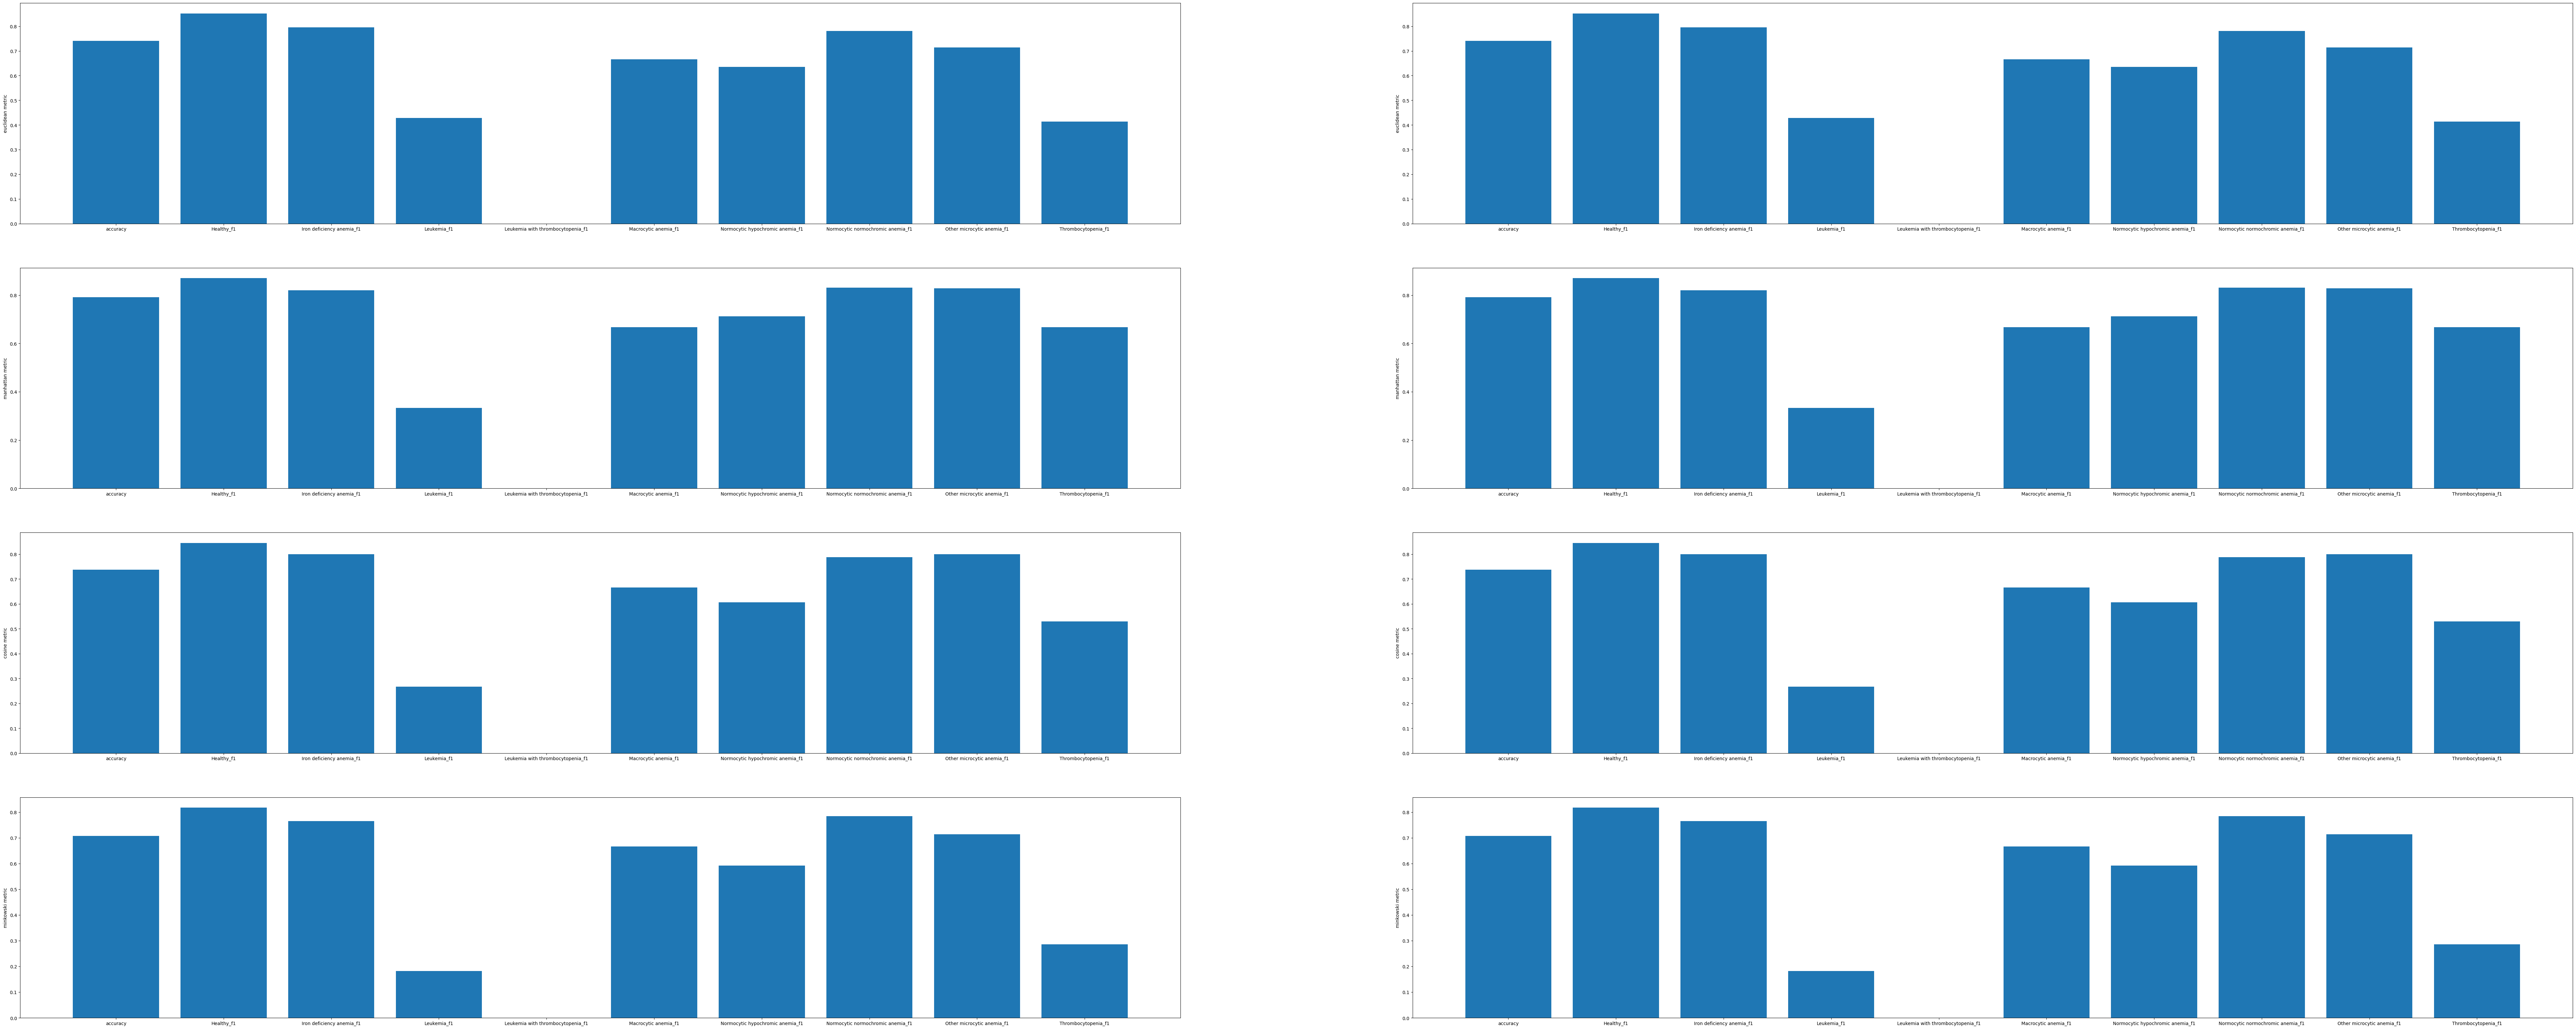

In [24]:
classifier = KNeighborsClassifier(n_neighbors=10, metric='manhattan')
classifier_custom = KNN(n_neighbors=10, metric='manhattan')

metric_names = ['euclidean', 'manhattan', 'cosine', 'minkowski']
    
metric_plots = plt.figure(figsize=(100,40)).subplots(4,2)

for m, i in zip(metric_names, range(len(metric_names))):
    classifier = KNeighborsClassifier(n_neighbors=10, metric=m, weights='uniform', p=3)
    classifier_custom = KNN(n_neighbors=10, metric=m, weights='uniform', p=3)

    classifier.fit(df_uniform.select_dtypes('float64'), df_uniform['Diagnosis'])
    classifier_custom.fit(df_uniform.select_dtypes('float64'), df_uniform['Diagnosis'])

    metric_plots[i][0].bar(
        x=['accuracy'] + [name + '_f1' for name in reverse_target_mapping.values()],
        height=np.concatenate([
                np.array([metrics.accuracy_score(df_uniform_test['Diagnosis'], classifier.predict(df_uniform_test.select_dtypes('float64')))]),
                metrics.f1_score(df_uniform_test['Diagnosis'], classifier.predict(df_uniform_test.select_dtypes('float64')), average=None)
            ])
        )
    metric_plots[i][0].set_ylabel(m + ' metric')

    metric_plots[i][1].bar(
        x=['accuracy'] + [name + '_f1' for name in reverse_target_mapping.values()],
        height=np.concatenate([
                np.array([metrics.accuracy_score(df_uniform_test['Diagnosis'], classifier_custom.predict(df_uniform_test.select_dtypes('float64')))]),
                metrics.f1_score(df_uniform_test['Diagnosis'], classifier_custom.predict(df_uniform_test.select_dtypes('float64')), average=None)
            ])
        )
    metric_plots[i][1].set_ylabel(m + ' metric')



Видно, как f1 score меняется в зависимости от метрики, в целом лучше всего работает расстояние Евклида.

Для того чтобы подобрать гиперпараметры, будем использовать grid search как самый простой метод. То сеть по сути переберем все возможные комбинации параметров.

In [25]:
print(KNeighborsClassifier().get_params())
print(KNN().get_params())

{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
{'metric': 'euclidean', 'n_neighbors': 10, 'p': 2, 'weights': 'uniform'}


Посмотрим какие метрики можно использовать для разных алгоритмов в `KNeighborsClassifier`.

In [26]:
from sklearn.neighbors import VALID_METRICS

for al in ['ball_tree','kd_tree','brute']:
    print(VALID_METRICS[al])

['euclidean', 'l2', 'minkowski', 'p', 'manhattan', 'cityblock', 'l1', 'chebyshev', 'infinity', 'seuclidean', 'mahalanobis', 'hamming', 'canberra', 'braycurtis', 'jaccard', 'dice', 'rogerstanimoto', 'russellrao', 'sokalmichener', 'sokalsneath', 'haversine', 'pyfunc']
['euclidean', 'l2', 'minkowski', 'p', 'manhattan', 'cityblock', 'l1', 'chebyshev', 'infinity']
['braycurtis', 'canberra', 'chebyshev', 'cityblock', 'correlation', 'cosine', 'dice', 'euclidean', 'hamming', 'haversine', 'jaccard', 'l1', 'l2', 'mahalanobis', 'manhattan', 'minkowski', 'nan_euclidean', 'precomputed', 'rogerstanimoto', 'russellrao', 'seuclidean', 'sokalsneath', 'sqeuclidean', 'yule']


Теперь применим `GridSearchCV` для перебора гиперпараметров.

In [ ]:
from sklearn.model_selection import GridSearchCV

params = [
{
    'algorithm':['ball_tree','kd_tree'],
    'leaf_size':list(range(1,50)),
    'metric':['minkowski', 'manhattan', 'euclidean'],
    'p':list(range(3, 20)),
    'weights':['uniform', 'distance'],
    'n_neighbors':list(range(1,20))
},
{
    'algorithm':['auto', 'brute'],
    'leaf_size':list(range(1,50)),
    'metric':['minkowski', 'cosine', 'manhattan', 'euclidean'],
    'p':list(range(3, 20)),
    'weights':['uniform', 'distance'],
    'n_neighbors':list(range(1,20))
}
]

params_custom = {
    'metric':['euclidean', 'minkowski', 'manhattan', 'cosine'],
    'n_neighbors':list(range(1,20)),
    'p':list(range(3, 20)),
    'weights':['uniform', 'distance']
}

gs = GridSearchCV(KNeighborsClassifier(), params, scoring='f1_macro', n_jobs=60)
gs_custom = GridSearchCV(KNN(), params_custom, scoring='f1_macro', n_jobs=60)

gs.fit(df_uniform.select_dtypes('float64').values, df_uniform['Diagnosis'].values)
gs_custom.fit(df_uniform.select_dtypes('float64').values, df_uniform['Diagnosis'].values)

best_params = gs.best_params_
best_params_custom = gs_custom.best_params_


c:\Users\anton\Desktop\ML_course_famcs\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Теперь посмотрим что получилось на выходе.

In [37]:
print(best_params)
print(best_params_custom)
print(gs.best_score_)
print(gs_custom.best_score_)

{'algorithm': 'ball_tree', 'leaf_size': 1, 'metric': 'minkowski', 'p': 1, 'weights': 'distance'}
{'metric': 'minkowski', 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
0.7241580195119074
0.7531595223529522
